# Assignment 2, Part A: Simon's Algorithm
### 1. Import Libraries
First, we import the necessary Qiskit classes for building our circuits, simulating the results, and visualizing the output histograms.

In [1]:
# Import necessary libraries
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Set up the simulator backend
backend = Aer.get_backend('aer_simulator')

### 2. Initialization and First Hadamard Layer
For Simon's algorithm, if our secret string $s$ has a length of $n$, we need $2n$ qubits total: $n$ for the query register (input) and $n$ for the ancilla register (output). 

Here, our secret string is **$s = 011$**, so $n = 3$. We need 6 qubits total and 3 classical bits to measure the query register.
We start by applying Hadamard gates to the input register to create an equal superposition of all possible states.

In [2]:
# Secret string for Part A
s = '011'
n = len(s)

# Create a circuit with 2n qubits (3 query, 3 ancilla) and n classical bits
qc_simon = QuantumCircuit(n*2, n)

# Apply Hadamard gates to the query register (qubits 0, 1, 2)
qc_simon.h(range(n))
qc_simon.barrier(); # Semicolon suppresses messy output

### 3. Simon's Oracle for $s = 011$
The oracle must satisfy the promise $f(x) = f(x \oplus s)$. To do this in Qiskit:
1. We first copy the query register to the ancilla register using CNOT gates.
2. We find the index of the first '1' in our secret string.
3. We apply a CNOT from that specific query qubit to the ancilla qubits wherever the secret string has a '1'. This creates the required 2-to-1 collision.

In [3]:
# Step 1: Copy the contents of the query register to the ancilla register
for i in range(n):
    qc_simon.cx(i, i+n)

# Step 2 & 3: Create the 2-to-1 mapping
# Reverse the string to match Qiskit's Little-Endian qubit ordering (q0 is the rightmost bit)
s_rev = s[::-1] 

# Find the index of the first '1' in the reversed string
m = s_rev.find('1')

# Apply the collision logic
for i in range(n):
    if s_rev[i] == '1':
        qc_simon.cx(m, i+n)

qc_simon.barrier();

### 4. Second Hadamard Layer and Measurement
After the oracle, we apply a second layer of Hadamard gates to the query register. This creates interference that destructively cancels out any states that do not satisfy the equation $u \cdot s = 0 \pmod 2$. 

Finally, we measure the query register.

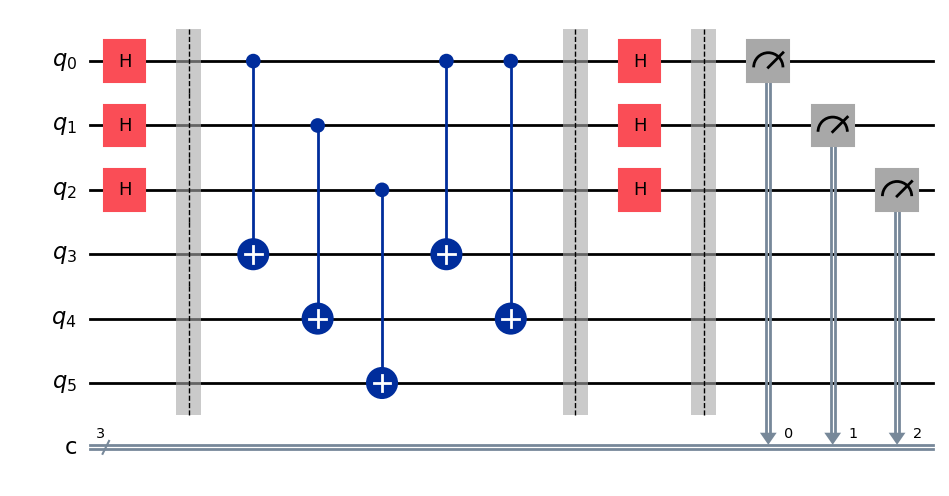

In [4]:
# Apply second layer of Hadamard gates to the query register
qc_simon.h(range(n))
qc_simon.barrier()

# Measure the query register (qubits 0, 1, 2) into the classical bits
qc_simon.measure(range(n), range(n))

# Draw the circuit (no semicolon here so the image prints!)
qc_simon.draw('mpl')

### 5. Execution and Analysis
We run the simulation with 2000 shots. 
Because $s = 011$, the equation $u \cdot s = 0 \pmod 2$ simplifies to:
$(u_2 \cdot 0) \oplus (u_1 \cdot 1) \oplus (u_0 \cdot 1) = 0 \implies u_1 \oplus u_0 = 0$.

This means the bits $u_1$ and $u_0$ must always be the same. The valid bitstrings we should measure are exactly `000`, `011`, `100`, and `111`.

Measured bitstrings for s = '011':
{'011': 518, '000': 492, '111': 499, '100': 491}


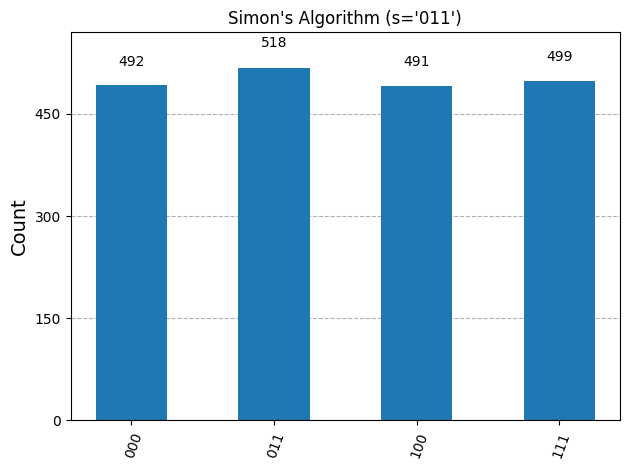

In [5]:
# Execute the circuit
job = backend.run(qc_simon, shots=2000)
counts = job.result().get_counts()

print(f"Measured bitstrings for s = '{s}':")
print(counts)

# Plot the histogram to verify we only get the valid bitstrings
plot_histogram(counts, title="Simon's Algorithm (s='011')")